In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
import hls4ml
from hls4ml.utils import config_from_keras_model

2026-01-26 17:16:49.815265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/mnt/Research/Rheed-FOLO/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
# Image Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

In [6]:
# Generate Gaussian Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    label = np.zeros(shape=(LABEL_Y, LABEL_X, 1))
    params = []

    num_gaussians = np.random.randint(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS)
    for gaussian in range(num_gaussians):

        # Randomize params
        center_x = np.random.randint(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = np.random.randint(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
        std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
        theta = np.random.randint(low=MIN_THETA, high=MAX_THETA)
        
        intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)
        
        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta)

        # Add Gaussian to img
        img += intensity * gaussian
        # img += gaussian
        
        label_x = center_x // SCALE_FACTOR
        label_y = center_y // SCALE_FACTOR

        label[label_y, label_x] = 1

    # Convert to 8 bit int
    img = (img * 255).astype(np.uint8)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        print(f"[Target Gaussians #]: {str(num_gaussians)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (img, label, params)

def gaussian_gen(center_x: int, center_y: int, std_x: int, std_y: int, theta: float) -> np.ndarray:
    
    X = np.arange(0, IMAGE_X, 1)
    Y = np.arange(0, IMAGE_Y, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.pow(np.cos(theta),2)
    sin_theta_sqrd = np.pow(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.pow(std_x, 2)
    std_y_sqrd = np.pow(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, label: np.ndarray, params: list = None, threshold: int = THRESHOLD) -> None:
    
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Coords of Gaussians:
    for x in range(LABEL_X):
        for y in range(LABEL_Y):
            if label[y, x,] >= threshold:
                
                top_left = (x * SCALE_FACTOR - GAUSSIAN_X // 2, y * SCALE_FACTOR - GAUSSIAN_Y // 2)
                bottom_right = (x * SCALE_FACTOR + GAUSSIAN_X // 2, y * SCALE_FACTOR + GAUSSIAN_Y // 2)
                color = (0, 200, 200)
                thickness = 2
                
                cv2.rectangle(rgb_image, top_left, bottom_right, color, thickness)

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )
    
    plt.imshow(rgb_image)

def img_visualization_two(img: np.ndarray, label: np.ndarray, params: list = None) -> None:
    
    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='gray')

In [7]:
# Create Validation Dataset #
VAL_COUNT = 1

img_arr_val = []
label_arr_val = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        # img_arr.append(img / (np.max(img) + 1)) # Normalize values to [0, 1)
        img_arr_val.append(np.round(img.astype(np.float32) / (np.max(img.astype(np.float32)) + 1) * 256) / 256) # Normalize values to [0, 1)
        label_arr_val.append(label)

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)



print(f'[Validation Shape]: {img_arr_val.shape}')


100%|██████████| 1/1 [00:00<00:00, 48.71it/s]

[Validation Shape]: (1, 256, 256, 1)


In [2]:
# Load Custom Objects

def loss_p(y_true, y_pred):
    loss = tf.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss)

In [3]:
# Load Model #
PROJECT_PATH = '/mnt/Research/Rheed-FOLO/folo_hls4ml'

with tf.keras.utils.custom_object_scope({
        'loss_p': loss_p,
}):
    keras_model = tf.keras.models.load_model(f'{PROJECT_PATH}/keras_model.keras')

config = config_from_keras_model(keras_model, granularity='name', backend='Vitis')
config['Model']['Strategy'] = 'Latency'
config['Model']['ReuseFactor'] = 1
# config['Model']['Precision'] = 'ap_fixed<16,6>'
hls_model = hls4ml.converters.convert_from_keras_model(
    keras_model,
    hls_config=config,
    output_dir='folo_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    default_precision='fixed<32,16>',
    part='xcku035-fbva676-2-e',
    project_name='folo'
)

I0000 00:00:1769476638.307170   59918 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5060 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


In [ ]:
# Compile Model #

hls_model.compile()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


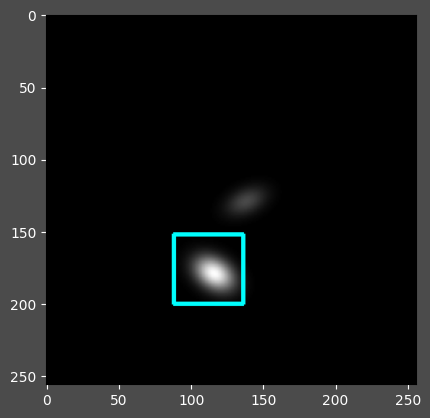

In [ ]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

# predictions_tf = keras_model(img_arr_val)
predictions_hls = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)
# img_visualization_one(img_arr_val[index], predictions_tf[index])
img_visualization_one(img_arr_val[index], predictions_hls[index])